# Nocarz — Budowa i porównanie modeli

Porównujemy **model bazowy** (najprostszy możliwy) i **model docelowy** (zaawansowany), zgodnie z Machine Learning Canvas.

| | Model A — bazowy | Model B — docelowy |
|---|---|---|
| Algorytm | średnia przychodu w dzielnicy | HistGradientBoostingRegressor |
| Cechy | tylko `neighbourhood_cleansed` | lokalizacja + typ + otoczenie rynkowe |
| Walidacja | Leave-One-District-Out (przestrzenna) | Leave-One-District-Out (przestrzenna) |

**Walidacja przestrzenna (Canvas):** ze względu na autokorelację przestrzenną zwykły losowy podział zawyża wynik (wyciek). Stosujemy `LeaveOneGroupOut` po dzielnicach (LODO) jako metrykę uczciwą; pokazujemy też wynik losowy dla kontrastu.

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd()
ROOT = next((q for q in [_p, *_p.parents] if (q / 'src' / 'nocarz').exists()), _p)
sys.path.insert(0, str(ROOT / 'src'))
# Drop any already-imported nocarz so edits to src/ are picked up without a kernel restart.
for _m in [k for k in list(sys.modules) if k == 'nocarz' or k.startswith('nocarz.')]:
    del sys.modules[_m]
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from nocarz.features import (PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, ALL_FEATURES, RADII_M,
                             TARGET, TARGET_OCCUPANCY, FeatureBuilder, compute_distance_features)
FIG = REPORTS_DIR / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
cv = pd.read_csv(PROCESSED_DIR / 'cv_metrics.csv')
cv

,target,model,cv,rmse,mae,r2,rmse_pct_of_std
0,revenue,A_baseline,random_kfold,48440.513117,30056.471351,0.019258,0.990319
1,revenue,A_baseline,spatial_LODO,48966.880162,30498.323145,-0.002171,1.001080
2,revenue,B_hgb,random_kfold,43895.596920,26246.004419,0.194660,0.897402
3,revenue,B_hgb,spatial_LODO,45243.451910,27124.971719,0.144444,0.924958
4,occupancy,A_baseline,random_kfold,0.367788,0.332183,0.022768,0.988545
5,occupancy,A_baseline,spatial_LODO,0.372558,0.339313,-0.002745,1.001366
6,occupancy,B_hgb,random_kfold,0.352579,0.309576,0.101920,0.947666
7,occupancy,B_hgb,spatial_LODO,0.357962,0.316203,0.074285,0.962136


## 1. Wyniki walidacji krzyżowej
Model B wyraźnie przewyższa baseline. Pod LODO baseline degeneruje się do średniej globalnej (R²≈0), a B utrzymuje sygnał przestrzenny (R²≈0.14).

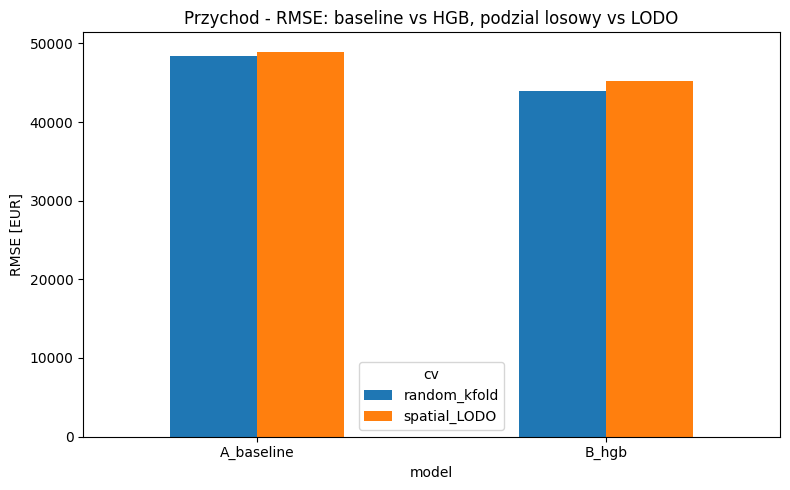

   target      model           cv         rmse          mae        r2  rmse_pct_of_std
  revenue A_baseline random_kfold 48440.513117 30056.471351  0.019258         0.990319
  revenue A_baseline spatial_LODO 48966.880162 30498.323145 -0.002171         1.001080
  revenue      B_hgb random_kfold 43895.596920 26246.004419  0.194660         0.897402
  revenue      B_hgb spatial_LODO 45243.451910 27124.971719  0.144444         0.924958
occupancy A_baseline random_kfold     0.367788     0.332183  0.022768         0.988545
occupancy A_baseline spatial_LODO     0.372558     0.339313 -0.002745         1.001366
occupancy      B_hgb random_kfold     0.352579     0.309576  0.101920         0.947666
occupancy      B_hgb spatial_LODO     0.357962     0.316203  0.074285         0.962136


In [2]:
piv = cv[cv['target'] == 'revenue'].pivot(index='model', columns='cv', values='rmse')
fig, ax = plt.subplots(figsize=(8, 5))
piv.plot(kind='bar', ax=ax)
ax.set(ylabel='RMSE [EUR]', title='Przychod - RMSE: baseline vs HGB, podzial losowy vs LODO')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout(); fig.savefig(FIG / 'model_cv_comparison.png', dpi=110); plt.show()
print(cv.to_string(index=False))

## 2. Ważność cech (permutation importance) — model B

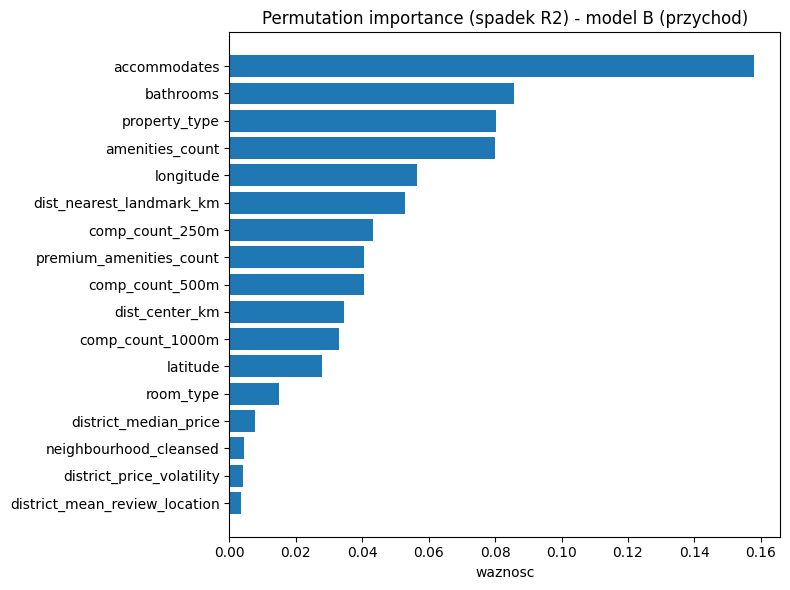

In [3]:
from sklearn.inspection import permutation_importance
df = pd.read_csv(PROCESSED_DIR / 'model_table.csv')
df = df[df[TARGET] <= df[TARGET].quantile(0.99)]
samp = df.sample(4000, random_state=0)
model_b = joblib.load(MODELS_DIR / 'model_b_revenue.joblib')
imp = permutation_importance(model_b, samp[ALL_FEATURES], samp[TARGET], n_repeats=4, random_state=0, scoring='r2')
order = np.argsort(imp.importances_mean)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(ALL_FEATURES)[order], imp.importances_mean[order])
ax.set(title='Permutation importance (spadek R2) - model B (przychod)', xlabel='waznosc')
fig.tight_layout(); fig.savefig(FIG / 'model_b_importance.png', dpi=110); plt.show()

## 3. Mapa potencjału i „białe plamy" (White Spots)
Zgodnie z Canvas: na siatce nałożonej na Paryż liczymy dla **profilu referencyjnego** (cały lokal, 4 osoby) wskaźnik potencjału opłacalności (WPF = predykcja przychodu modelu B) oraz **saturację rynku** (liczba ofert w 500 m). **Biała plama** = wysoki WPF i niska saturacja.

In [4]:
fb = FeatureBuilder.from_listings_csv()
model_b_occ = joblib.load(MODELS_DIR / 'model_b_occupancy.joblib')
lats = np.arange(48.815, 48.905, 0.0035); lons = np.arange(2.255, 2.420, 0.0035)
glon, glat = np.meshgrid(lons, lats)
glat = glat.ravel(); glon = glon.ravel()
xy = fb._project(glat, glon)
comp = {n: fb.tree.query_ball_point(xy, r, return_length=True).astype(float) for n, r in RADII_M.items()}
_, idx = fb.tree.query(xy, k=1)
districts = fb.ref['neighbourhood_cleansed'].to_numpy()[idx]
dist = compute_distance_features(glat, glon)
g = pd.DataFrame({'latitude': glat, 'longitude': glon, 'accommodates': 4, 'amenities_count': 25,
                  'bathrooms': float(fb.global_median_bathrooms), 'premium_amenities_count': 3,
                  'dist_center_km': dist['dist_center_km'],
                  'dist_nearest_landmark_km': dist['dist_nearest_landmark_km'],
                  'neighbourhood_cleansed': districts, 'property_type': 'Entire rental unit',
                  'room_type': 'Entire home/apt'})
for n in comp: g[n] = comp[n]
g['district_median_price'] = g['neighbourhood_cleansed'].map(fb.district_median_price)
g['district_price_volatility'] = (g['neighbourhood_cleansed'].map(fb.district_price_volatility)
                                  .fillna(fb.global_price_volatility))
g['district_mean_review_location'] = g['neighbourhood_cleansed'].map(fb.district_mean_review_location)
g['WPF'] = np.clip(model_b.predict(g[ALL_FEATURES]), 0, None)
g['pred_occupancy'] = np.clip(model_b_occ.predict(g[ALL_FEATURES]), 0, 1)
g = g[g['comp_count_1000m'] > 30]  # tylko obszar pokryty rynkiem (miasto)
wpf_thr = g['WPF'].quantile(0.70); sat_thr = g['comp_count_500m'].quantile(0.30)
g['white_spot'] = (g['WPF'] >= wpf_thr) & (g['comp_count_500m'] <= sat_thr)
print(f'Punktow siatki: {len(g)} | bialych plam: {int(g.white_spot.sum())}')

Punktow siatki: 1059 | bialych plam: 37


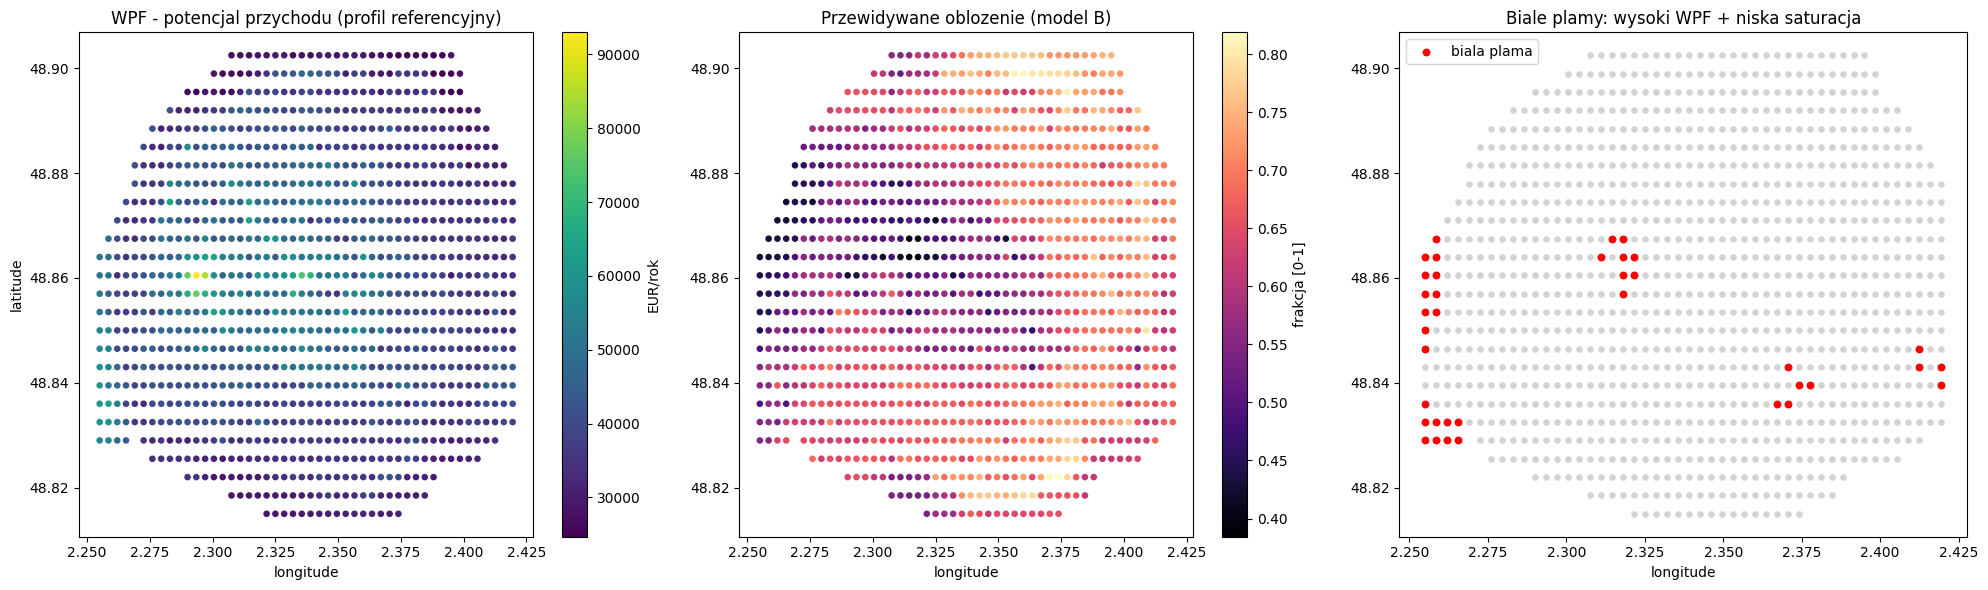

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
sc = ax[0].scatter(g['longitude'], g['latitude'], c=g['WPF'], cmap='viridis', s=14)
ax[0].set(title='WPF - potencjal przychodu (profil referencyjny)', xlabel='longitude', ylabel='latitude')
fig.colorbar(sc, ax=ax[0], label='EUR/rok')
so = ax[1].scatter(g['longitude'], g['latitude'], c=g['pred_occupancy'], cmap='magma', s=14)
ax[1].set(title='Przewidywane oblozenie (model B)', xlabel='longitude')
fig.colorbar(so, ax=ax[1], label='frakcja [0-1]')
ax[2].scatter(g['longitude'], g['latitude'], c='lightgray', s=14)
ws = g[g['white_spot']]
ax[2].scatter(ws['longitude'], ws['latitude'], c='red', s=22, label='biala plama')
ax[2].set(title='Biale plamy: wysoki WPF + niska saturacja', xlabel='longitude'); ax[2].legend()
fig.tight_layout(); fig.savefig(FIG / 'whitespot_map.png', dpi=110); plt.show()

In [6]:
# Top-N lokalizacji dla dzialu Business Development (ranking po WPF wsrod bialych plam)
top = ws.sort_values('WPF', ascending=False).head(10)[
    ['latitude', 'longitude', 'neighbourhood_cleansed', 'WPF', 'pred_occupancy', 'comp_count_500m']]
top.round({'WPF': 0, 'pred_occupancy': 2}).reset_index(drop=True)

,latitude,longitude,neighbourhood_cleansed,WPF,pred_occupancy,comp_count_500m
0,48.8605,2.3180,Palais-Bourbon,60986.0,0.52,156.0
1,48.8360,2.2550,Passy,59259.0,0.50,142.0
2,48.8325,2.2585,Passy,59240.0,0.56,16.0
3,48.8325,2.2550,Passy,59240.0,0.55,16.0
4,48.8605,2.3215,Palais-Bourbon,58806.0,0.52,178.0
5,48.8570,2.3180,Palais-Bourbon,57048.0,0.58,222.0
6,48.8465,2.2550,Passy,56374.0,0.49,219.0
7,48.8290,2.2585,Passy,55435.0,0.55,0.0
8,48.8290,2.2550,Passy,55435.0,0.55,0.0
9,48.8500,2.2550,Passy,54312.0,0.45,100.0


## Wnioski
- **Model B (HGB) > Model A (baseline)** na każdej metryce; przewaga utrzymuje się pod uczciwą walidacją przestrzenną (LODO).
- Niskie bezwzględne R² wynika ze świadomego pominięcia własnej ceny lokalu (cel = cena × obłożenie). Model nadal dobrze **różnicuje lokalizacje**, co wystarcza do rankingu „białych plam".
- Pipeline generuje mapę potencjału i listę Top-N lokalizacji — gotowy wsad dla działu Business Development (lead list z Canvas).